In [ ]:
pip install yfinance numpy scipy matplotlib plotly pandas

In [ ]:
import numpy as np
import pandas as pd

# Visualisation
import matplotlib.pyplot as plt
%matplotlib inline

# Scipy.stats
from scipy.stats import norm

# Random Generator
rng = np.random.default_rng(123)

import time
import yfinance as yf
import datetime as dt

In [ ]:
def MC_options_vectorized(S, K, T, r, sigma, N, option_type='call'):
    """
    Vectorized Monte Carlo simulation for European options
    """
    # Generate random numbers
    X = rng.normal(0, 1, N)

    # Calculate stock prices at expiration
    ST = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * X)

    # Calculate discounted payoffs
    if option_type == 'call':
        payoffs = np.exp(-r * T) * np.maximum(ST - K, 0)
    else:  # put
        payoffs = np.exp(-r * T) * np.maximum(K - ST, 0)

    # Calculate price and variance
    price = np.mean(payoffs)
    variance = np.var(payoffs)

    return price, variance

In [ ]:
def BS_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def BS_put(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return -S * norm.cdf(-d1) + K * np.exp(-r * T) * norm.cdf(-d2)

In [ ]:
"""
# Testcase 2: Parameter imported from yahoo! finance
def fetch_options_data(ticker_symbol):
    ticker = yf.Ticker(ticker_symbol)
    options_dates = ticker.options

    # Use the farthest expiration date to get more reasonable options
    expiry_str = options_dates[-1]

    options_data = ticker.option_chain(expiry_str)

    # Get current stock price
    S = ticker.history(period="1d")["Close"].iloc[-1]

    return options_data.calls, options_data.puts, expiry_str, S

# Example usage:
calls, puts, expiry_str, S = fetch_options_data('JPM')

# Call option
atm_call = calls.iloc[(calls['strike'] - S).abs().argsort()[:1]] # pick the at-the-money strike from the nearest expiry
K_call = atm_call['strike'].values[0]

atm_put = puts.iloc[(puts['strike'] - S).abs().argsort()[:1]]
K_put = atm_put['strike'].values[0]

T = 1.0

# Get risk-free rate
r = yf.Ticker("^IRX").history(period="1d")["Close"].iloc[-1] / 100

# Use a reasonable implied volatility value (around 0.3 is typical for stocks)
sigma_call = 0.3
sigma_put = 0.3

print(f"S: {S:.6f}")
print(f"Call - K: {K_call}, T: {T:.6f}, r: {r:.6f}, σ: {sigma_call:.6f}")
print(f"Put - K: {K_put}, T: {T:.6f}, r: {r:.6f}, σ: {sigma_put:.6f}")
"""

S: 309.190002
Call - K: 310.0, T: 1.000000, r: 0.038900, σ: 0.300000
Put - K: 310.0, T: 1.000000, r: 0.038900, σ: 0.300000


In [ ]:
#Testcase1: Hardcode
S = 60
K_call = 65
K_put = 55
T = 1.0
r = 0.03
sigma_call = 0.3
sigma_put = 0.3

In [ ]:
BS_call_price = BS_call(S, K_call, T, r, sigma_call)
BS_put_price = BS_put(S, K_put, T, r, sigma_put)

print(f"\nBlack-Scholes Call Price: {BS_call_price:.6f}")
print(f"Black-Scholes Put Price: {BS_put_price:.6f}")


Black-Scholes Call Price: 5.899266
Black-Scholes Put Price: 3.949577



N = 10000
Call: 5.908824 ± 0.223184 (Error: 5089.120857%)
Put: 3.914661 ± 0.124950 (Error: 6040.637854%)
Computation time: 0.002301 seconds

N = 100000
Call: 5.885808 ± 0.072046 (Error: 15912.315900%)
Put: 3.936883 ± 0.039858 (Error: 19259.332608%)
Computation time: 0.011827 seconds

N = 1000000
Call: 5.899618 ± 0.022735 (Error: 50760.838133%)
Put: 3.932802 ± 0.012576 (Error: 61191.415572%)
Computation time: 0.116396 seconds

N = 10000000
Call: 5.894832 ± 0.007189 (Error: 160607.374187%)
Put: 3.947262 ± 0.003985 (Error: 194042.987423%)
Computation time: 1.033265 seconds

N = 100000000
Call: 5.899697 ± 0.002275 (Error: 508110.054358%)
Put: 3.949772 ± 0.001260 (Error: 614083.174910%)
Computation time: 10.781417 seconds


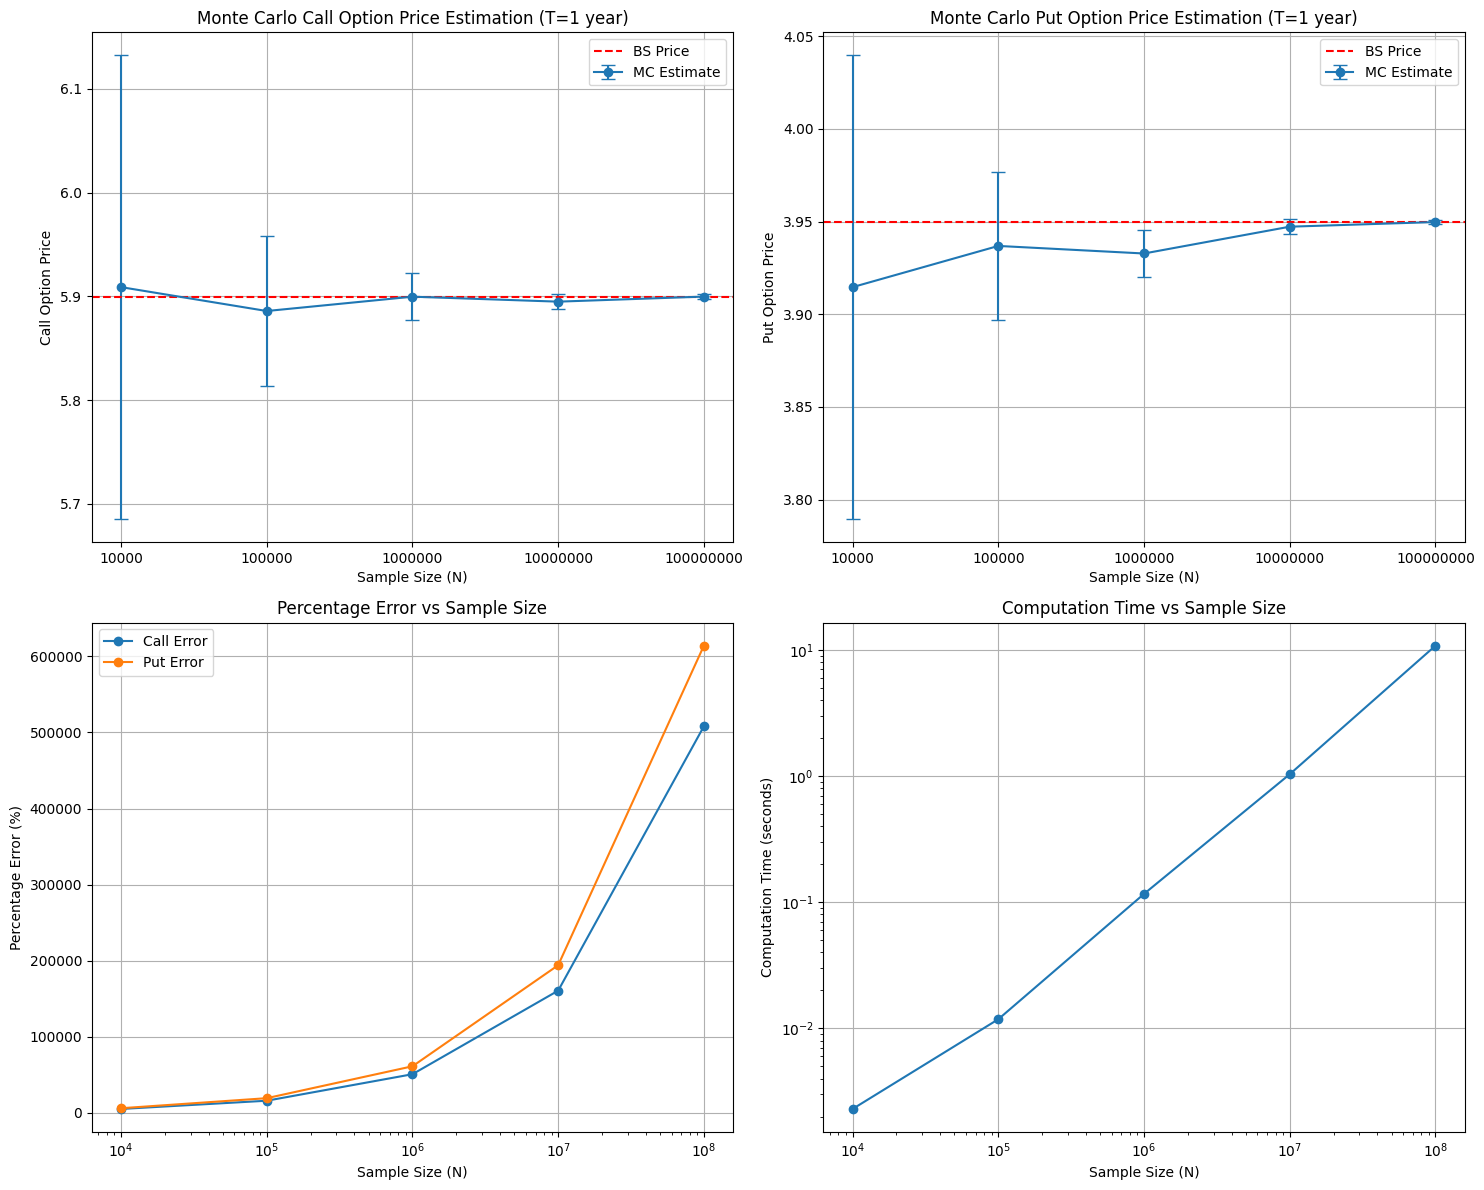


Percentage Errors:
Sample Size	Call Error (%)	Put Error (%)	Time (s)
10000		5089.120857		6040.637854		0.002301
100000		15912.315900		19259.332608		0.011827
1000000		50760.838133		61191.415572		0.116396
10000000		160607.374187		194042.987423		1.033265
100000000		508110.054358		614083.174910		10.781417

Standard Error of the Mean (SEM) Analysis:
Sample Size	Call SEM	Put SEM		1/sqrt(N)
10000		0.113869	0.063750	0.010000
100000		0.036758	0.020336	0.003162
1000000		0.011600	0.006417	0.001000
10000000		0.003668	0.002033	0.000316
100000000		0.001161	0.000643	0.000100


In [ ]:
# Compare Monte Carlo estimates for different sample sizes
sample_sizes = [10**4, 10**5, 10**6, 10**7, 10**8] # max is 10**8 for this program

call_results = []
put_results = []
computation_times = []

for N in sample_sizes:
    start_time = time.time()

    # Call option
    MC_call_price, var_call = MC_options_vectorized(S, K_call, T, r, sigma_call, N, 'call')
    SEM_call = np.sqrt(var_call / N)
    perc_error_call = abs(MC_call_price - SEM_call) / SEM_call * 100 if SEM_call > 0 else 0 # use SEM_call instead of BS_call_price which is a true value, this is important for monte carlo

    # Put option
    MC_put_price, var_put = MC_options_vectorized(S, K_put, T, r, sigma_put, N, 'put')
    SEM_put = np.sqrt(var_put / N)
    perc_error_put = abs(MC_put_price - SEM_put) / SEM_put * 100 if SEM_put >0 else 0

    end_time = time.time()
    computation_time = end_time - start_time
    computation_times.append(computation_time)

    call_results.append({
        'N': N,
        'price': MC_call_price,
        'SEM': SEM_call,
        'perc_error': perc_error_call
    })

    put_results.append({
        'N': N,
        'price': MC_put_price,
        'SEM': SEM_put,
        'perc_error': perc_error_put
    })

    print(f"\nN = {N}")
    print(f"Call: {MC_call_price:.6f} ± {1.96*SEM_call:.6f} (Error: {perc_error_call:.6f}%)")
    print(f"Put: {MC_put_price:.6f} ± {1.96*SEM_put:.6f} (Error: {perc_error_put:.6f}%)")
    print(f"Computation time: {computation_time:.6f} seconds")

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

# Call option results
ax1.errorbar([str(x) for x in sample_sizes],
             [res['price'] for res in call_results],
             yerr=[1.96*res['SEM'] for res in call_results],
             fmt='o-', capsize=5, label='MC Estimate')
ax1.axhline(y=BS_call_price, color='r', linestyle='--', label='BS Price')
ax1.set_xlabel('Sample Size (N)')
ax1.set_ylabel('Call Option Price')
ax1.set_title('Monte Carlo Call Option Price Estimation (T=1 year)')
ax1.legend()
ax1.grid(True)

# Put option results
ax2.errorbar([str(x) for x in sample_sizes],
             [res['price'] for res in put_results],
             yerr=[1.96*res['SEM'] for res in put_results],
             fmt='o-', capsize=5, label='MC Estimate')
ax2.axhline(y=BS_put_price, color='r', linestyle='--', label='BS Price')
ax2.set_xlabel('Sample Size (N)')
ax2.set_ylabel('Put Option Price')
ax2.set_title('Monte Carlo Put Option Price Estimation (T=1 year)')
ax2.legend()
ax2.grid(True)

# Percentage error plot
ax3.semilogx(sample_sizes, [res['perc_error'] for res in call_results], 'o-', label='Call Error')
ax3.semilogx(sample_sizes, [res['perc_error'] for res in put_results], 'o-', label='Put Error')
ax3.set_xlabel('Sample Size (N)')
ax3.set_ylabel('Percentage Error (%)')
ax3.set_title('Percentage Error vs Sample Size')
ax3.legend()
ax3.grid(True)

# Computation time plot
ax4.loglog(sample_sizes, computation_times, 'o-')
ax4.set_xlabel('Sample Size (N)')
ax4.set_ylabel('Computation Time (seconds)')
ax4.set_title('Computation Time vs Sample Size')
ax4.grid(True)

plt.tight_layout()
plt.show()

# Display percentage errors
print("\nPercentage Errors:")
print("Sample Size\tCall Error (%)\tPut Error (%)\tTime (s)")
for i, N in enumerate(sample_sizes):
    print(f"{N}\t\t{call_results[i]['perc_error']:.6f}\t\t{put_results[i]['perc_error']:.6f}\t\t{computation_times[i]:.6f}")

# Additional analysis: Show how SEM decreases with sample size
print("\nStandard Error of the Mean (SEM) Analysis:")
print("Sample Size\tCall SEM\tPut SEM\t\t1/sqrt(N)")
for i, N in enumerate(sample_sizes):
    print(f"{N}\t\t{call_results[i]['SEM']:.6f}\t{put_results[i]['SEM']:.6f}\t{1/np.sqrt(N):.6f}")

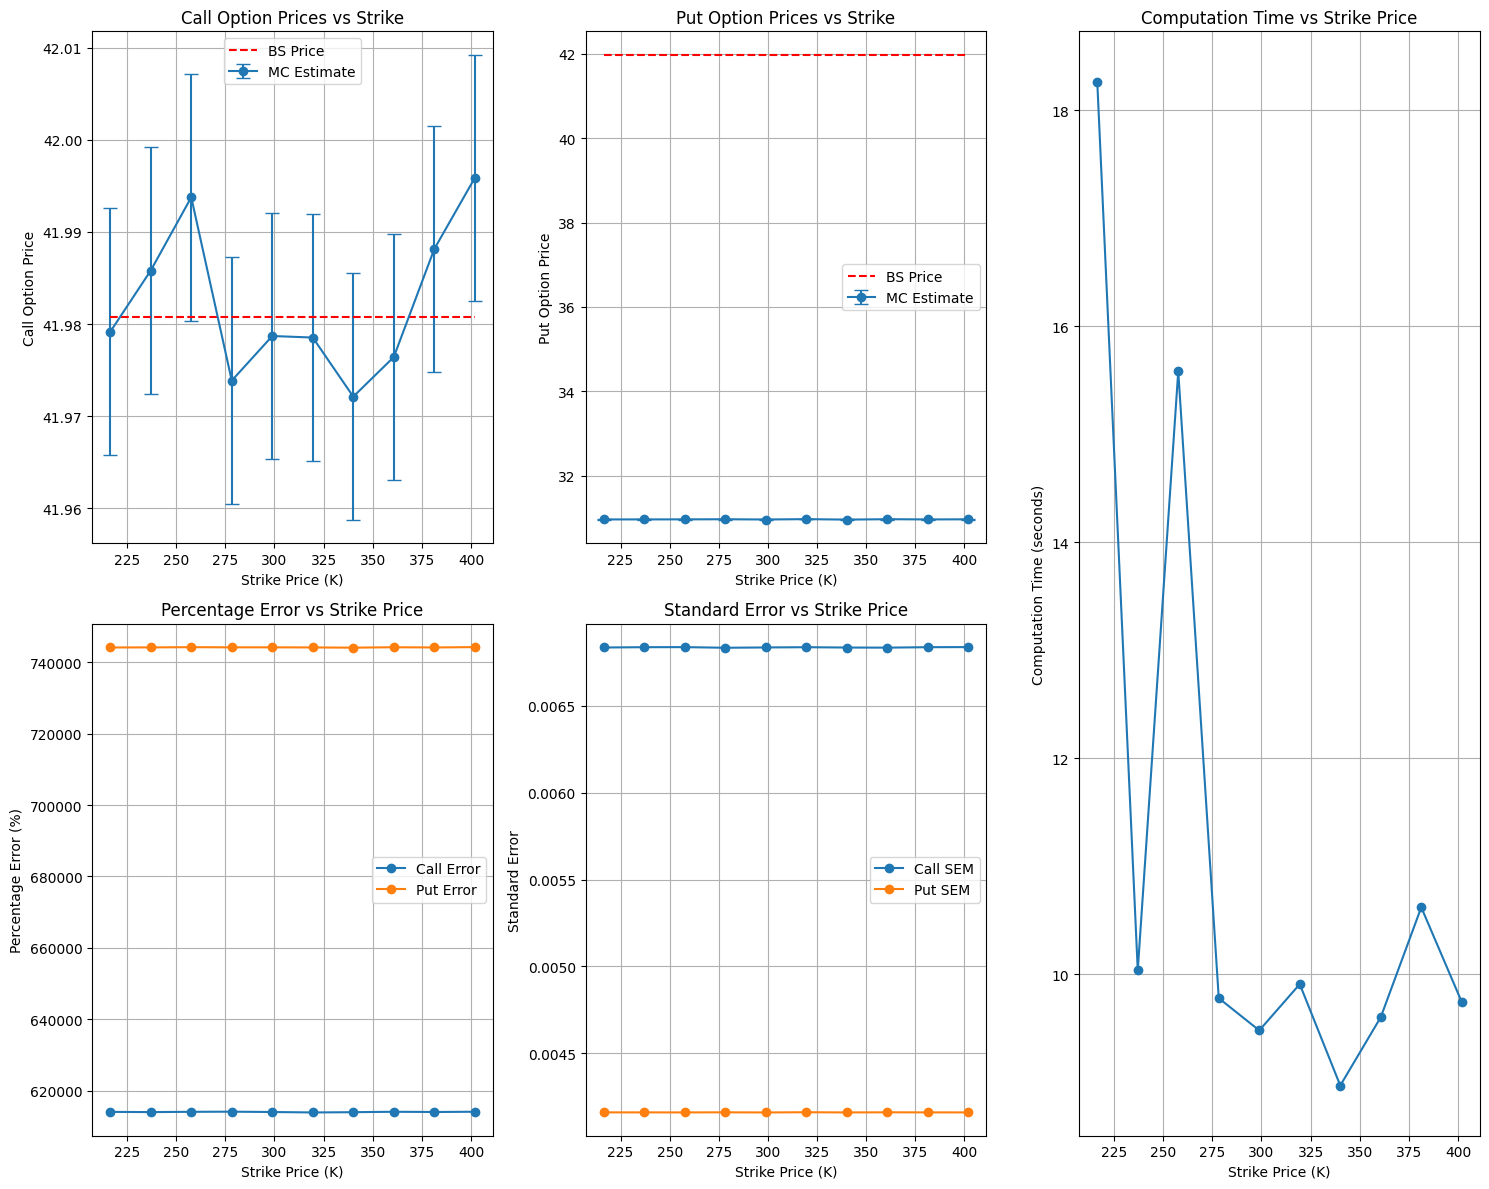


Detailed Results:
Strike		Call MC		Call BS		Call Err%	Put MC		Put BS		Put Err%	Time(s)
216.433002		41.979155	41.980784	614087.033967		30.962891	41.980784	744102.562901	18.263872
237.045669		41.985813	41.980784	614029.208837		30.963133	41.980784	744125.248394	10.037504
257.658335		41.993769	41.980784	614107.048542		30.964155	41.980784	744183.973431	15.582776
278.271002		41.973853	41.980784	614144.017922		30.966841	41.980784	744142.427355	9.780236
298.883669		41.978699	41.980784	614053.396435		30.960987	41.980784	744143.007208	9.481663
319.496336		41.978532	41.980784	613927.309739		30.969249	41.980784	744111.351082	9.909858
340.109003		41.972114	41.980784	614002.830604		30.958382	41.980784	744053.110177	8.971767
360.721670		41.976411	41.980784	614118.664994		30.968132	41.980784	744164.629869	9.604208
381.334336		41.988143	41.980784	614057.663557		30.962470	41.980784	744104.673760	10.620940
401.947003		41.995867	41.980784	614125.305350		30.965470	41.980784	744207.184612	9.744535


In [ ]:
# Compare Monte Carlo estimates for different strike prices
strike_range = np.linspace(0.7 * S, 1.3 * S, 10)
N = 10**8

call_results = []
put_results = []
computation_times = []

for K in strike_range:
    start_time = time.time()

    # Call option
    MC_call_price, var_call = MC_options_vectorized(S, K_call, T, r, sigma_call, N, 'call')
    SEM_call = np.sqrt(var_call / N)
    perc_error_call = abs(MC_call_price - SEM_call) / SEM_call * 100 if BS_call_price > 0 else 0

    # Put option
    MC_put_price, var_put = MC_options_vectorized(S, K_put, T, r, sigma_put, N, 'put')
    SEM_put = np.sqrt(var_put / N)
    perc_error_put = abs(MC_put_price - SEM_put) / SEM_put * 100

    end_time = time.time()
    computation_time = end_time - start_time
    computation_times.append(computation_time)

    call_results.append({
        'K': K,
        'MC_price': MC_call_price,
        'BS_price': BS_call_price,
        'SEM': SEM_call,
        'perc_error': perc_error_call
    })

    put_results.append({
        'K': K,
        'MC_price': MC_put_price,
        'BS_price': BS_call_price,
        'SEM': SEM_put,
        'perc_error': perc_error_put
    })

fig = plt.figure(figsize=(15, 12))
gs = fig.add_gridspec(2, 3)

# Call option results
ax1 = fig.add_subplot(gs[0, 0])
ax1.errorbar(strike_range,
             [res['MC_price'] for res in call_results],
             yerr=[1.96*res['SEM'] for res in call_results],
             fmt='o-', capsize=5, label='MC Estimate')
ax1.plot(strike_range, [res['BS_price'] for res in call_results],
         'r--', label='BS Price')
ax1.set_xlabel('Strike Price (K)')
ax1.set_ylabel('Call Option Price')
ax1.set_title('Call Option Prices vs Strike')
ax1.legend()
ax1.grid(True)

# Put option results
ax2 = fig.add_subplot(gs[0, 1])
ax2.errorbar(strike_range,
             [res['MC_price'] for res in put_results],
             yerr=[1.96*res['SEM'] for res in put_results],
             fmt='o-', capsize=5, label='MC Estimate')
ax2.plot(strike_range, [res['BS_price'] for res in put_results],
         'r--', label='BS Price')
ax2.set_xlabel('Strike Price (K)')
ax2.set_ylabel('Put Option Price')
ax2.set_title('Put Option Prices vs Strike')
ax2.legend()
ax2.grid(True)

# Percentage error plot
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(strike_range, [res['perc_error'] for res in call_results],
         'o-', label='Call Error')
ax3.plot(strike_range, [res['perc_error'] for res in put_results],
         'o-', label='Put Error')
ax3.set_xlabel('Strike Price (K)')
ax3.set_ylabel('Percentage Error (%)')
ax3.set_title('Percentage Error vs Strike Price')
ax3.legend()
ax3.grid(True)

# Standard Error plot
ax4 = fig.add_subplot(gs[1, 1])
ax4.plot(strike_range, [res['SEM'] for res in call_results],
         'o-', label='Call SEM')
ax4.plot(strike_range, [res['SEM'] for res in put_results],
         'o-', label='Put SEM')
ax4.set_xlabel('Strike Price (K)')
ax4.set_ylabel('Standard Error')
ax4.set_title('Standard Error vs Strike Price')
ax4.legend()
ax4.grid(True)

# Computation time plot
ax5 = fig.add_subplot(gs[:, 2])
ax5.plot(strike_range, computation_times, 'o-')
ax5.set_xlabel('Strike Price (K)')
ax5.set_ylabel('Computation Time (seconds)')
ax5.set_title('Computation Time vs Strike Price')
ax5.grid(True)

plt.tight_layout()
plt.show()

# Display detailed results
print("\nDetailed Results:")
print("Strike\t\tCall MC\t\tCall BS\t\tCall Err%\tPut MC\t\tPut BS\t\tPut Err%\tTime(s)")
for i, K in enumerate(strike_range):
    print(f"{K:.6f}\t\t{call_results[i]['MC_price']:.6f}\t{call_results[i]['BS_price']:.6f}\t"
          f"{call_results[i]['perc_error']:.6f}\t\t{put_results[i]['MC_price']:.6f}\t"
          f"{put_results[i]['BS_price']:.6f}\t{put_results[i]['perc_error']:.6f}\t{computation_times[i]:.6f}")